In [ ]:
import os
import numpy as np
import scipy.ndimage as ndimage
from skimage.morphology import skeletonize
from scipy.ndimage import distance_transform_edt
import SimpleITK as sitk


def get_shortest_path_between_farest_points(skeleton : np.ndarray) -> np.ndarray:
    z,y,x = np.nonzero(skeleton)
    skeleton_neighbors = {}

    for i in range(len(z)):
        z_coord, y_coord, x_coord = z[i], y[i], x[i]
        neighbors = []
        
        for j in range(len(z)):
            if i == j:
                continue
            z_neighbor, y_neighbor, x_neighbor = z[j], y[j], x[j]
            dx = abs(x_neighbor - x_coord)
            dy = abs(y_neighbor - y_coord)
            dz = abs(z_neighbor - z_coord)
            if dx <= 1 and dy <= 1 and dz <= 1:
                neighbors.append((z_neighbor, y_neighbor, x_neighbor))

        skeleton_neighbors[(z_coord, y_coord, x_coord)] = neighbors

    farest_points = ()
    longest_distance = 0.0
    longest_distance_idx = (0, 0)

    for i in range(len(z)):
        for j in range(i + 1, len(z)):
            point1 = (z[i], y[i], x[i])
            point2 = (z[j], y[j], x[j])
            distance = np.sqrt((point1[0] - point2[0]) ** 2 + (point1[1] - point2[1]) ** 2 + (point1[2] - point2[2]) ** 2)
            
            if distance > longest_distance:
                longest_distance = distance
                longest_distance_idx = (i, j)

    farest_points = (longest_distance, (z[longest_distance_idx[0]], y[longest_distance_idx[0]], x[longest_distance_idx[0]]), (z[longest_distance_idx[1]], y[longest_distance_idx[1]], x[longest_distance_idx[1]]))

    shortest_path = find_shortest_path(farest_points[1], farest_points[2], skeleton_neighbors)
    return shortest_path

def find_shortest_path(start_point : tuple, end_point : tuple, skeleton_neighbors : dict) -> np.ndarray:
    from collections import deque
    visited = set()
    queue = deque([(start_point, [start_point])])  # (current_point, path_to_current)
    
    while queue:
        current_point, path = queue.popleft()
        
        if current_point == end_point:
            return np.array(path)
        
        if current_point in visited:
            continue
        
        visited.add(current_point)
        
        for neighbor in skeleton_neighbors.get(current_point, []):
            if neighbor not in visited:
                queue.append((neighbor, path + [neighbor]))
    
    return np.array([])  # Nincs út a két pont között

def compute_hessian_at_coords(image: np.ndarray, coords: tuple, sigma: float) -> np.ndarray:
    """
    Kiszámolja a Hesse-mátrixot a megadott koordinátákra egy adott skálán (sigma).
    Kimenete: (Pontok_száma, 3, 3) alakú numpy tömb.
    """
    sz, sy, sx = coords
    num_points = len(sz)

    # A deriváltakat a teljes képen számoljuk a Gauss elmosás miatt
    s2 = sigma**2
    Dzz = ndimage.gaussian_filter(image, sigma, order=[2, 0, 0]) * s2
    Dyy = ndimage.gaussian_filter(image, sigma, order=[0, 2, 0]) * s2
    Dxx = ndimage.gaussian_filter(image, sigma, order=[0, 0, 2]) * s2
    Dzy = ndimage.gaussian_filter(image, sigma, order=[1, 1, 0]) * s2
    Dzx = ndimage.gaussian_filter(image, sigma, order=[1, 0, 1]) * s2
    Dyx = ndimage.gaussian_filter(image, sigma, order=[0, 1, 1]) * s2

    # Hesse-mátrix építése CSAK a koordináták pontjainál
    H_skel = np.zeros((num_points, 3, 3), dtype=np.float32)
    H_skel[:, 0, 0] = Dzz[sz, sy, sx]
    H_skel[:, 0, 1] = Dzy[sz, sy, sx]
    H_skel[:, 0, 2] = Dzx[sz, sy, sx]
    H_skel[:, 1, 0] = Dzy[sz, sy, sx]
    H_skel[:, 1, 1] = Dyy[sz, sy, sx]
    H_skel[:, 1, 2] = Dyx[sz, sy, sx]
    H_skel[:, 2, 0] = Dzx[sz, sy, sx]
    H_skel[:, 2, 1] = Dyx[sz, sy, sx]
    H_skel[:, 2, 2] = Dxx[sz, sy, sx]

    return H_skel

def calculate_c_in_skeleton(binary: np.ndarray, skeleton: np.ndarray, sigmas: list) -> float:
    """
    Kiszámolja a c paramétert a csőszerűséghez képlethez a kép intenzitásának statisztikái alapján.
    """
    global_max_S = 0
    skeleton_coords = np.nonzero(skeleton)
    for s in sigmas:
        print("Mátrix építés és sajátérték-számítás...")
        
        H_skel = compute_hessian_at_coords(binary, skeleton_coords, s)
        eigvals = np.linalg.eigvalsh(H_skel)

        # S = H abs értékének kiszámítása
        S = np.sqrt(np.sum(eigvals**2, axis=-1))
        
        # A zaj kiszűrése és a max/percentilis keresése
        valid_S = S[S > 1e-6]
        if len(valid_S) > 0:
            current_max = np.percentile(valid_S, 99)
        else:
            current_max = 0.0
        
        print(f"Skála: {s}, 99%-os percentilis S: {current_max}")
            
        if current_max > global_max_S:
            global_max_S = current_max

    c = global_max_S / 1.5
    c = max(c, 1e-6)
    return c

def evaluate_tubeness_on_skeleton(l1: np.ndarray, l2: np.ndarray, l3: np.ndarray, alpha: float, beta: float, c: float) -> np.ndarray:
    eps = 1e-10
        
    abs_l1, abs_l2, abs_l3 = np.abs(l1), np.abs(l2), np.abs(l3)

    R_plate = abs_l2 / (abs_l3 + eps)
    R_blob = abs_l1 / (np.sqrt(abs_l2 * abs_l3) + eps)
    S = np.sqrt(l1**2 + l2**2 + l3**2)

    scores = (1 - np.exp(-(R_plate**2) / (2 * alpha**2))) * \
             np.exp(-(R_blob**2) / (2 * beta**2)) * \
             (1 - np.exp(-(S**2) / (2 * c**2)))
             
    scores[(l3 > -0.1) | (l2 > -0.05)] = 0
    # debug print
    for i in range(len(scores)):
        print(f"Pont {i}: l1={l1[i]:.4f}, l2={l2[i]:.4f}, l3={l3[i]:.4f}, R_plate={R_plate[i]:.4f}, R_blob={R_blob[i]:.4f}, S={S[i]:.4f}, score={scores[i]:.4f}")
            
    return np.nan_to_num(scores)

def multiscale_tubeness_3d(image: np.ndarray, skeleton: np.ndarray, sigmas: list, alpha=0.5, beta=0.1, c=None) -> dict:
    """
    Többskálás szűrés (tubeness) a skeleton pontjain.
    """
    if c is None:
        c = calculate_c_in_skeleton(image, skeleton, sigmas)
        print(f"Használt c érték a tubeness képlethez: {c}")

    max_scores = np.zeros_like(image, dtype=np.float32)
    best_eigenvectors = np.zeros(image.shape + (3,), dtype=np.float32)

    coords = np.nonzero(skeleton)
    sz, sy, sx = coords
    num_points = len(sz)
    print(f"Összesen {num_points} darab skeleton pontot vizsgálunk.")

    for s in sigmas:
        print(f" -> Számítás sigma = {s} skálán (tubeness)...")
        
        H = compute_hessian_at_coords(image, coords, s)

        # Sajátértékek és sajátvektorok kiszámítása
        eigvals, eigvecs = np.linalg.eigh(H)

        abs_eigvals = np.abs(eigvals)
        sort_indices = np.argsort(abs_eigvals, axis=-1)

        l1 = np.take_along_axis(eigvals, sort_indices[..., 0:1], axis=-1)[..., 0]
        l2 = np.take_along_axis(eigvals, sort_indices[..., 1:2], axis=-1)[..., 0]
        l3 = np.take_along_axis(eigvals, sort_indices[..., 2:3], axis=-1)[..., 0]

        # L1 sajátvektor (a vágósík normálvektora)
        u1_indices = sort_indices[..., 0]
        # U1 vektor kiválasztása, id_repeated kell a megfelelő dimenziószám miatt
        idx_repeated = np.repeat(np.expand_dims(u1_indices, axis=(-2, -1)), 3, axis=-2)
        u1_current = np.take_along_axis(eigvecs, idx_repeated, axis=-1)[..., 0]

        scores = evaluate_tubeness_on_skeleton(l1, l2, l3, alpha, beta, c)

        # Visszamappelés a teljes 3D képre
        scores_full = np.zeros_like(image, dtype=np.float32)
        scores_full[sz, sy, sx] = scores
        scores = scores_full

        u1_full = np.zeros(image.shape + (3,), dtype=np.float32)
        u1_full[sz, sy, sx, :] = u1_current
        u1_current = u1_full

        # Frissítjük a maximumokat
        better_mask = scores > max_scores
        max_scores[better_mask] = scores[better_mask]
        best_eigenvectors[better_mask] = u1_current[better_mask]

    print("\nSzűrés kész! Maximális válaszok kigyűjtve.")
    return {
        'scores': max_scores,
        'eigenvectors': best_eigenvectors
    }


def get_max_tubeness_indices(scores_on_skel, eigenvectors_on_skel, sz, sy, sx) -> tuple[tuple[int, int, int], np.ndarray]:
    if len(scores_on_skel) == 0:
        return (-1, -1, -1), np.array([0.0, 0.0, 0.0])
    
    max_idx = int(np.argmax(scores_on_skel))
    max_score = scores_on_skel[max_idx]
    
    p_z, p_y, p_x = int(sz[max_idx]), int(sy[max_idx]), int(sx[max_idx])
    normal_vector: np.ndarray = eigenvectors_on_skel[max_idx]
    
    print(f"Megtalálva: Z: {p_z}, {max_score}")
    print(f"Vágási pont megtalálva: Z={p_z}, Y={p_y}, X={p_x}, Normál vektor: {normal_vector}")
    return (p_z, p_y, p_x), normal_vector

In [428]:
def get_smoothed(scale: int, ventricle_label: np.ndarray, tube_label: np.ndarray) -> np.ndarray:
    distance = 1 * scale
    iterations = 5
    
    smoothed_ventricle = ndimage.binary_dilation(ventricle_label, iterations=iterations)
    smoothed_ventricle = ndimage.binary_erosion(smoothed_ventricle, iterations=iterations)
    
    print(f"Skála: {scale}, Távolság a kamrához és csőhöz: {distance}, Iterációk száma: {iterations}")
      
    dist_to_ventricle = distance_transform_edt(~ventricle_label)
    
    tubular_tube = (dist_to_ventricle < distance) & tube_label
    
    unio = smoothed_ventricle | tubular_tube
    
    smoothed = ndimage.binary_dilation(unio, iterations=3)
    smoothed = ndimage.binary_erosion(smoothed, iterations=3)
    
    return smoothed.astype(np.uint8)


def get_dummy_plane(ventricle_label: np.ndarray, tube_label: np.ndarray, ct_array: np.ndarray = None, ct_image: sitk.Image = None, out_dir: str = None, ventricle_type: str = None, tube_type: str = None) -> tuple[np.ndarray, np.ndarray]:
    """
    Keres egy vágósíkot a kamra és a cső (pl. aorta) között, amely elválasztja a kettőt.
    
    Args:
        ventricle_label: a kamra maszkja (pl. bal kamra)
        tube_label: a cső maszkja (pl. aorta)
        ct_array: A CT kép a vizualizációhoz (opcionális)
        ct_image: A CT kép a vizualizációhoz (opcionális)
        out_dir: A kimeneti könyvtár elérési útvonala (opcionális)
        ventricle_type: A kamra típusa (pl. bal kamra)
        tube_type: A cső típusa (pl. aorta)
    Returns:
        visual_plane_mask: A sík megjelenítéshez használt maszkja (néhány voxel vastag).
        half_space_mask: Egy bináris maszk, amellyel vágni lehet a kamrát 
                         (True a sík "alatt/mögött", False az eldobandó részen).
    """
    out_dir += f"_{tube_type}" if tube_type else ""
    if out_dir is not None:
        os.makedirs(out_dir, exist_ok=True)
        
    scale = 0.5
    while True:
        smoothed = get_smoothed(scale=scale, ventricle_label=ventricle_label, tube_label=tube_label)
        skeleton = skeletonize(smoothed)
        
        # Szigetek keresése 26-os szomszédsággal
        struct_26 = ndimage.generate_binary_structure(3, 3)
        labeled_skeleton, num_features = ndimage.label(skeleton, structure=struct_26)
        
        if num_features > 0:
            # Legnagyobb sziget megkeresése (a bincount 0. eleme a háttér, azt kihagyjuk)
            sizes = np.bincount(labeled_skeleton.flat)[1:]
            largest_label = np.argmax(sizes) + 1
            main_skeleton = (labeled_skeleton == largest_label)
            
            main_path = get_shortest_path_between_farest_points(main_skeleton)
            
            main_path_mask = np.zeros_like(main_skeleton, dtype=np.uint8)
            if len(main_path) > 0:
                main_path_mask[tuple(main_path.T)] = 1
            print(f"Fő útvonal mérete: {main_path_mask.sum()} voxel.")
            
            # a main path nem csak a kamrában, de a csőben is megy, akkor az jó
            if tube_label[main_path_mask.astype(bool)].sum() > 3:
                
                print(f"Fő útvonal mérete: {main_path_mask.sum()} voxel.")
                print(f"Megfelelő fő útvonal találva a kamra és cső között.{tube_label[main_path_mask.astype(bool)].sum()} ")
                
                dilated_skeleton = ndimage.binary_dilation(main_skeleton, iterations=1)
                output.save_image(dilated_skeleton.astype(np.uint8), os.path.join(out_dir, "dilated_main_skeleton.nii.gz"))
                output.save_image(smoothed.astype(np.uint8), os.path.join(out_dir, "smoothed.nii.gz"))
                dilated_main_path = ndimage.binary_dilation(main_path_mask, iterations=1)
                output.save_image(dilated_main_path.astype(np.uint8), os.path.join(out_dir, "dilated_main_path.nii.gz"))
                break
            else:
                scale += 1.0
        else:
            scale += 1.5
            
    # Region of Interest meghatározása az átmenet kereséséhez, a fő vonal 10%-a
    cut_len = int(len(main_path) * 0.1) 
    bottleneck_path = main_path[:cut_len]

    # A binary_mask lehet az 'interesting_region', vagy az aorta/kamra eredeti uniója is.
    # Fontos, hogy ez az a vastag maszk legyen, aminek a falától a távolságot mérjük!
    distance_map = distance_transform_edt(smoothed.astype(bool))
    
    if len(bottleneck_path) > 0:
        radii_in_voxels = distance_map[tuple(bottleneck_path.T)] # át kell alakítani koordinátákká
    else:
        radii_in_voxels = []

    if len(radii_in_voxels) > 0:
        mean_r = np.mean(radii_in_voxels)
        filtered_radii = radii_in_voxels[radii_in_voxels < mean_r]
        bottleneck_radius = np.median(filtered_radii) if len(filtered_radii) > 0 else np.median(radii_in_voxels)
        min_r = np.min(radii_in_voxels)
        max_r = np.max(radii_in_voxels)
        median_r = np.median(radii_in_voxels)
        
        
        print(f"\nAz ér/kamra szakasz sugarai a skeleton mentén (voxelben):")
        print(f"  Minimum sugár: {min_r:.2f}")
        print(f"  Maximum sugár: {max_r:.2f}")
        print(f"  Átlagos sugár: {mean_r:.2f}")
        
        # Dinamikus sigmák
        dynamic_sigmas = np.linspace(min(min_r, 1.0), max(max_r, 5.0), num=10).tolist()
        print(f"  --> Automatikusan javasolt szigmák a szűrőhöz: {dynamic_sigmas}")
    else:
        print("Nem található skeleton pont a távolságok kinyeréséhez.")
        # Ha egyáltalán nincs érték, adjunk egy biztonságos fallback listát!
        dynamic_sigmas = [1.0, 2.0, 3.0,  4.0, 5.0, 6.0]

    z_idx, y_idx, x_idx = np.nonzero(smoothed)

    z_min: int = max(0, z_idx.min())
    z_max: int = min(smoothed.shape[0], z_idx.max() + 1)
        
    y_min: int = max(0, y_idx.min())
    y_max: int = min(smoothed.shape[1], y_idx.max() + 1)
        
    x_min: int = max(0, x_idx.min())
    x_max: int = min(smoothed.shape[2], x_idx.max() + 1)
    
    # CT kivágása
    smoothed_cropped = smoothed[z_min:z_max, y_min:y_max, x_min:x_max]
    skeleton_cropped = main_skeleton[z_min:z_max, y_min:y_max, x_min:x_max]
    main_path_cropped = main_path_mask[z_min:z_max, y_min:y_max, x_min:x_max]
    
    # A fő vonal alsó 20%-át levágjuk, hogy ez ne zavarjon
    cut_len = int(len(main_path) * 0.2) 
    interesting_path = main_path[cut_len:]
    
    # EREDETI MÉRETŰ maszkot készítünk, beleírjuk az 1-eseket
    interesting_mask_full = np.zeros_like(main_skeleton, dtype=np.uint8)
    if len(interesting_path) > 0:
        interesting_mask_full[tuple(interesting_path.T)] = 1
        
    # Majd ezt VÁGJUK KI a kisebb bounding boxra
    interesting_mask_cropped = interesting_mask_full[z_min:z_max, y_min:y_max, x_min:x_max]
            
    print(f"Kivágott doboz mérete: Z:{z_max-z_min}, Y:{y_max-y_min}, X:{x_max-x_min}")
    tubeness_result = multiscale_tubeness_3d(
            image=smoothed_cropped.astype(np.float32), 
            sigmas=dynamic_sigmas,
            skeleton=interesting_mask_cropped, 
            alpha=0.25, # annyira nem fontos, hogy a cső két kersztmetszete hasonló legyen 
            beta=1.0
        )
    
    scores_cropped = tubeness_result['scores']
    eigenvectors_cropped = tubeness_result['eigenvectors']
    
    # Pontosan azon a maszkon keressük a nem-nulla értékeket, amin a tubeness-t lefuttattuk
    z_skel, y_skel, x_skel = np.nonzero(interesting_mask_cropped) 
    
    # Kinyerjük az értékeket pontosan a skeleton pontjain
    scores_on_skel = scores_cropped[z_skel, y_skel, x_skel]
    eigenvectors_on_skel = eigenvectors_cropped[z_skel, y_skel, x_skel]

    # Maximális csőszerűségi értékek vizualizálása
    # x : z. index
    # y: csőszerűsége a maximálisnak ezen z índexen 

    max_scores_per_z = {}
    for z, score in zip(z_skel, scores_on_skel):
        max_scores_per_z[z] = max(max_scores_per_z.get(z, 0), score)

    # Plotolás
    import matplotlib.pyplot as plt
    plt.figure(figsize=(10, 6))
    plt.plot(list(max_scores_per_z.keys()), list(max_scores_per_z.values()), marker='o')
    plt.title('Maximális és átlagos csőszerűségi értékek a skeleton mentén Z szerint')
    plt.xlabel('Z index')
    plt.ylabel('Csőszerűségi érték')
    plt.grid()
    plt.savefig(os.path.join(out_dir, "max_tubeness_along_skeleton.png"))
    plt.show()
    
    #output.save_image(scores_on_skel, os.path.join(out_dir, "scores_on_skeleton.nii.gz"))

    (p_z, p_y, p_x), normal_vector = get_max_tubeness_indices(
            scores_on_skel=scores_on_skel,
            eigenvectors_on_skel=eigenvectors_on_skel,
            sz=z_skel,
            sy=y_skel,
            sx=x_skel,
        )

    # --- SÍK GENERÁLÁSA ---
    n_z, n_y, n_x = normal_vector[0], normal_vector[1], normal_vector[2]

    # Eredeti, nem vágott koordinátarendszerbe való visszaállítás
    p_z += z_min
    p_y += y_min
    p_x += x_min

    print(f"Vágási pont megtalálva: Z={p_z}, Y={p_y}, X={p_x}, Normál vektor: {normal_vector}")

    shape = ventricle_label.shape
    Z, Y, X = np.ogrid[0:shape[0], 0:shape[1], 0:shape[2]]
        
    plane_equation = n_z * (Z - p_z) + n_y * (Y - p_y) + n_x * (X - p_x)

    visual_plane_mask = np.abs(plane_equation) <= 2.0

    # Irány korrigálása, hogy a Z tengely (fej felé) vágjon lefelé
    if n_z > 0:
        plane_equation = -plane_equation

    half_space_mask = plane_equation > 0 
    # vizualizációs ellenőrzéshez
    print(f"Vágási pont megtalálva: Z={p_z}, Y={p_y}, X={p_x}")
    print("A vágási sík a cső és a kamra között")
    save_path_3d = out_dir + f"/cutting_plane_overlay_3d_{tube_type}.png" if out_dir else None
    visualization.plot_3d_slices_with_labels(ct_array, {tube_type : tube_label, ventricle_type : ventricle_label, 'cutting_plane': visual_plane_mask}, slice_indices=(z_center, y_center, x_center), save_path=save_path_3d)

    return visual_plane_mask, half_space_mask

In [1]:
import argparse
import os
import numpy as np
import SimpleITK as sitk

from soveny import tube_BB
from soveny import config
from soveny import input
from soveny import label
from soveny import ventircles_BB
from soveny import visualization
from soveny import septum_BB
from soveny import filter
from soveny import output
from soveny import resample

In [411]:
dataset = "ImageCHD_dataset" 
dataset_dir, cfg = config.load_config(dataset)

In [430]:
dataset_dir = os.path.join(dataset_dir, "preprocessed")  # Resampled könyvtár használata most az ImageCHD_dataset-ben, ahol már izotrópra van resample-elve a CT és a label is.

image_path, label_path = input.get_input_paths(dataset_dir)
ct_image, ct_array, label_image, label_array = input.load_ct_and_label(image_path, label_path)

Eredeti CT spacing (X, Y, Z): (1.0, 1.0, 1.0)
Image neve: ct_1005_image_iso.nii.gz
Label neve: ct_1005_label_iso.nii.gz


In [431]:
output_dir = output.derive_output_dir(image_path, dataset)
output_dir.mkdir(parents=True, exist_ok=True)
print(f"Output directory: {output_dir}")

Output directory: output\ImageCHD_dataset\ct_1005_iso


Azonosított címkék: [0 1 2 3 4 6 7]


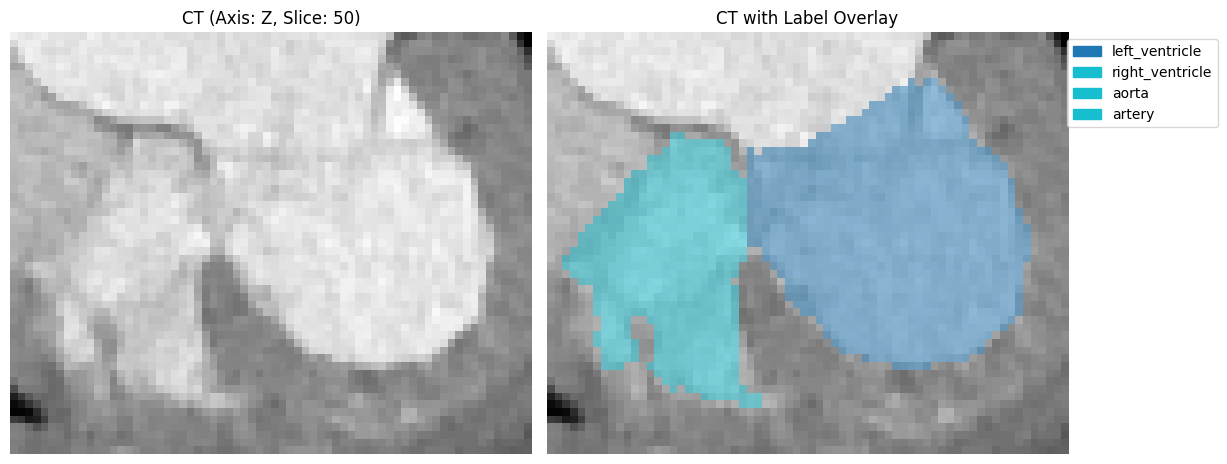

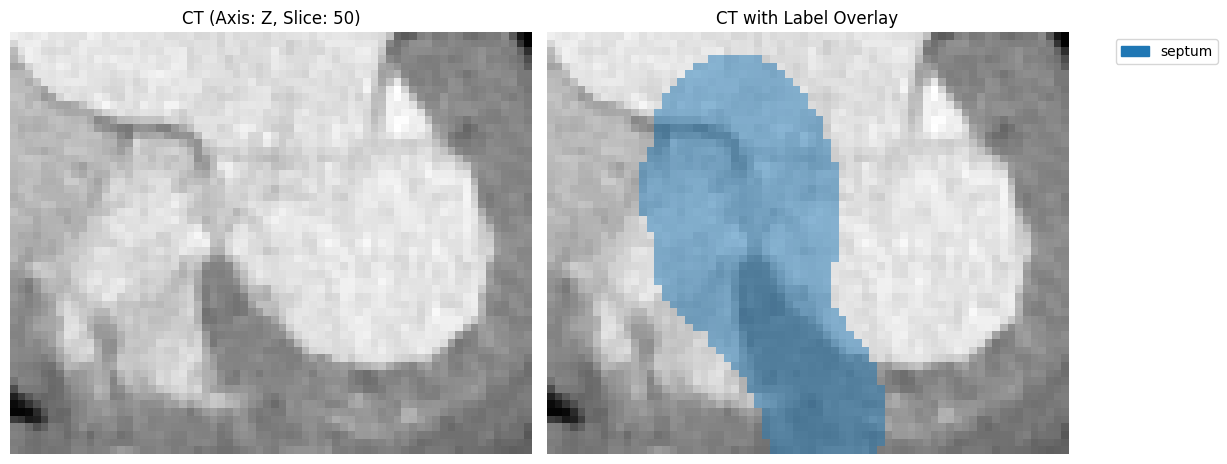

In [432]:

relevant_labels_dic = label.extract_labels(label_array, cfg)

    
roi_mask = relevant_labels_dic['left_ventricle'] | relevant_labels_dic['right_ventricle']
    
cropped_ct_array, cropped_relevant_labels_dic = ventircles_BB.crop_to_roi(
        ct_array, 
        relevant_labels_dic, 
        roi_mask
)
    
visualization.plot_slice_with_labels(cropped_ct_array, cropped_relevant_labels_dic, axis='z', save_path=os.path.join(output_dir, 'ventricles_overlay.png'))
    
septum_mask = septum_BB.get_septum_by_distance(
        cropped_relevant_labels_dic['left_ventricle'],
        cropped_relevant_labels_dic['right_ventricle'],
        max_distance_mm=12
)
    
visualization.plot_slice_with_labels(cropped_ct_array, {'septum': septum_mask,}, axis='z', save_path=os.path.join(output_dir, 'septum_overlay.png'))


Skála: 0.5, Távolság a kamrához és csőhöz: 0.5, Iterációk száma: 5
Fő útvonal mérete: 87 voxel.
Skála: 1.5, Távolság a kamrához és csőhöz: 1.5, Iterációk száma: 5
Fő útvonal mérete: 88 voxel.
Skála: 2.5, Távolság a kamrához és csőhöz: 2.5, Iterációk száma: 5
Fő útvonal mérete: 89 voxel.
Skála: 3.5, Távolság a kamrához és csőhöz: 3.5, Iterációk száma: 5
Fő útvonal mérete: 91 voxel.
Skála: 4.5, Távolság a kamrához és csőhöz: 4.5, Iterációk száma: 5
Fő útvonal mérete: 90 voxel.
Skála: 5.5, Távolság a kamrához és csőhöz: 5.5, Iterációk száma: 5
Fő útvonal mérete: 92 voxel.
Skála: 6.5, Távolság a kamrához és csőhöz: 6.5, Iterációk száma: 5
Fő útvonal mérete: 93 voxel.
Skála: 7.5, Távolság a kamrához és csőhöz: 7.5, Iterációk száma: 5
Fő útvonal mérete: 105 voxel.
Fő útvonal mérete: 105 voxel.
Megfelelő fő útvonal találva a kamra és cső között.10 
Sikeres mentés: output\ImageCHD_dataset\ct_1005_iso\aorta_cutting_plane_aorta\dilated_main_skeleton.nii.gz
Sikeres mentés: output\ImageCHD_dataset

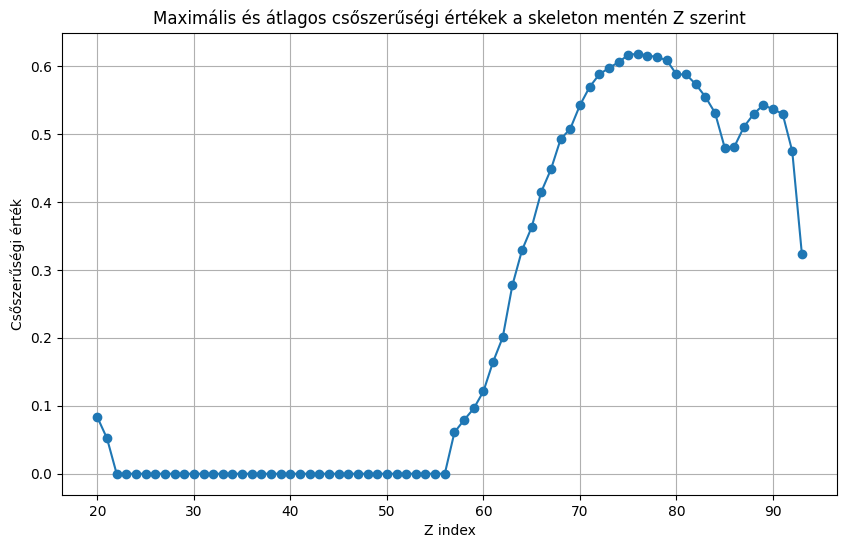

Megtalálva: Z: 76, 0.6182842254638672
Vágási pont megtalálva: Z=76, Y=18, X=23, Normál vektor: [ 0.7470285  -0.06813654 -0.661291  ]
Vágási pont megtalálva: Z=116, Y=50, X=75, Normál vektor: [ 0.7470285  -0.06813654 -0.661291  ]
Vágási pont megtalálva: Z=116, Y=50, X=75
A vágási sík a cső és a kamra között


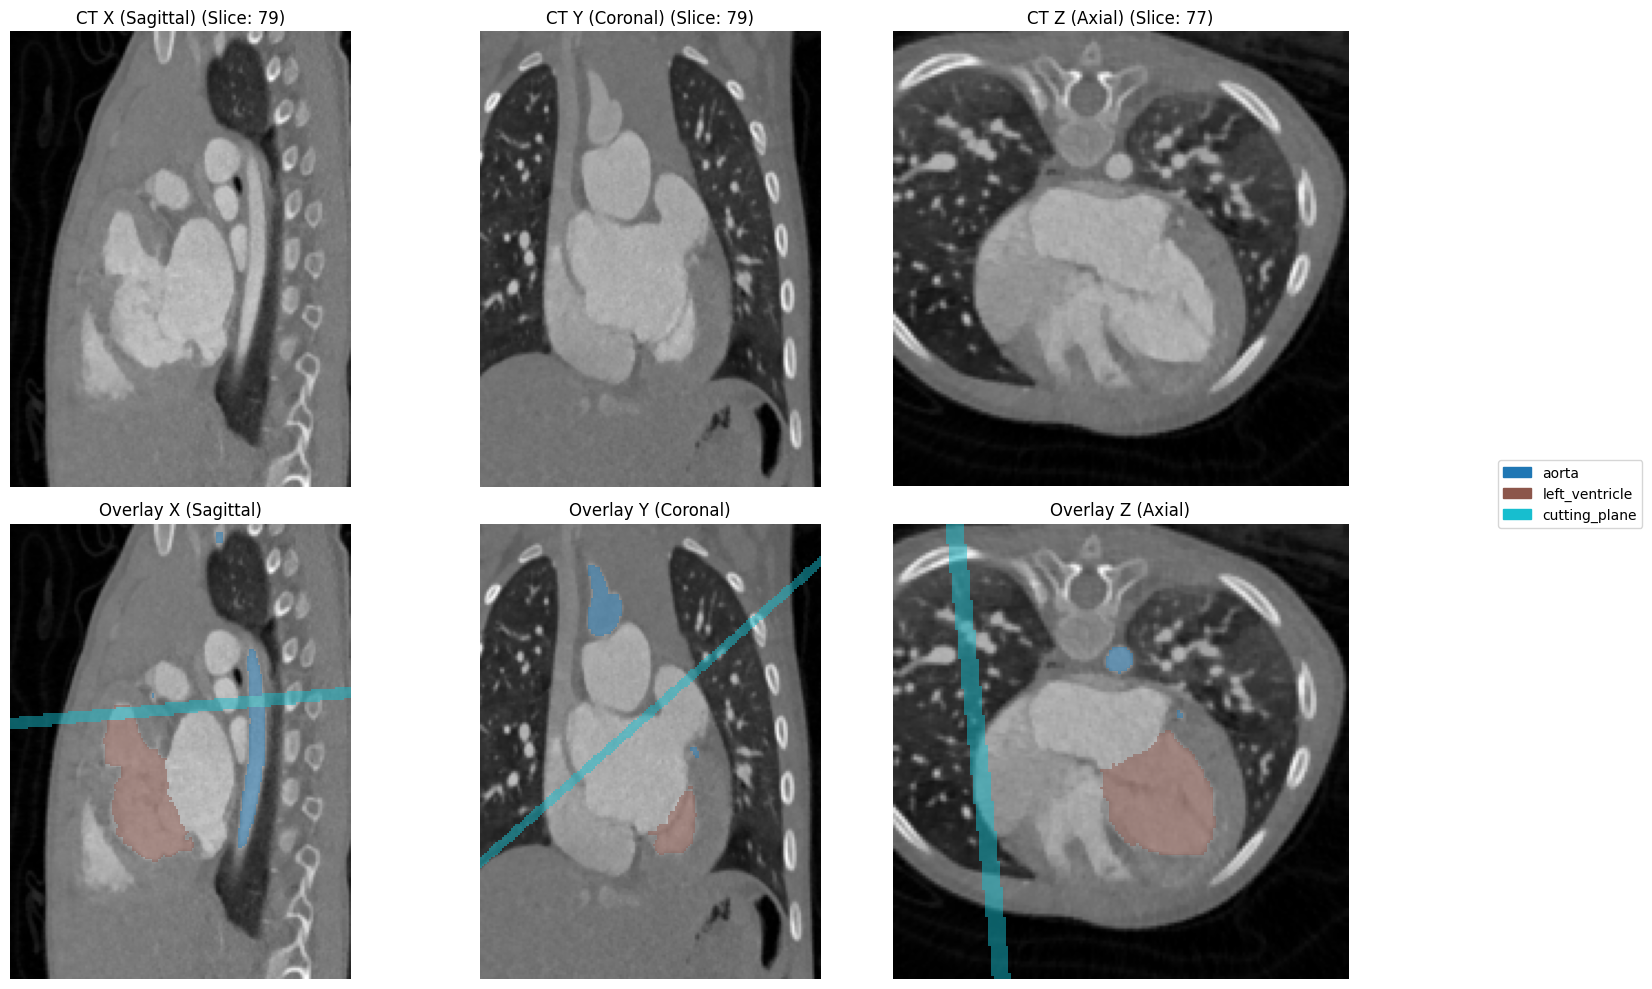

In [433]:
visual_plane_aorta, cut_mask_aorta = get_dummy_plane(
        ventricle_label=relevant_labels_dic['left_ventricle'],
        tube_label=relevant_labels_dic['aorta'],
        ct_array=ct_array,
        ct_image=ct_image,
        out_dir=os.path.join(output_dir, "aorta_cutting_plane"),
        tube_type='aorta',
        ventricle_type='left_ventricle'
    )

Skála: 0.5, Távolság a kamrához és csőhöz: 0.5, Iterációk száma: 5
Fő útvonal mérete: 76 voxel.
Skála: 1.5, Távolság a kamrához és csőhöz: 1.5, Iterációk száma: 5
Fő útvonal mérete: 79 voxel.
Skála: 2.5, Távolság a kamrához és csőhöz: 2.5, Iterációk száma: 5
Fő útvonal mérete: 80 voxel.
Skála: 3.5, Távolság a kamrához és csőhöz: 3.5, Iterációk száma: 5
Fő útvonal mérete: 78 voxel.
Skála: 4.5, Távolság a kamrához és csőhöz: 4.5, Iterációk száma: 5
Fő útvonal mérete: 80 voxel.
Skála: 5.5, Távolság a kamrához és csőhöz: 5.5, Iterációk száma: 5
Fő útvonal mérete: 83 voxel.
Skála: 6.5, Távolság a kamrához és csőhöz: 6.5, Iterációk száma: 5
Fő útvonal mérete: 80 voxel.
Skála: 7.5, Távolság a kamrához és csőhöz: 7.5, Iterációk száma: 5
Fő útvonal mérete: 83 voxel.
Fő útvonal mérete: 83 voxel.
Megfelelő fő útvonal találva a kamra és cső között.6 
Sikeres mentés: output\ImageCHD_dataset\ct_1005_iso\artery_cutting_plane_artery\dilated_main_skeleton.nii.gz
Sikeres mentés: output\ImageCHD_dataset\

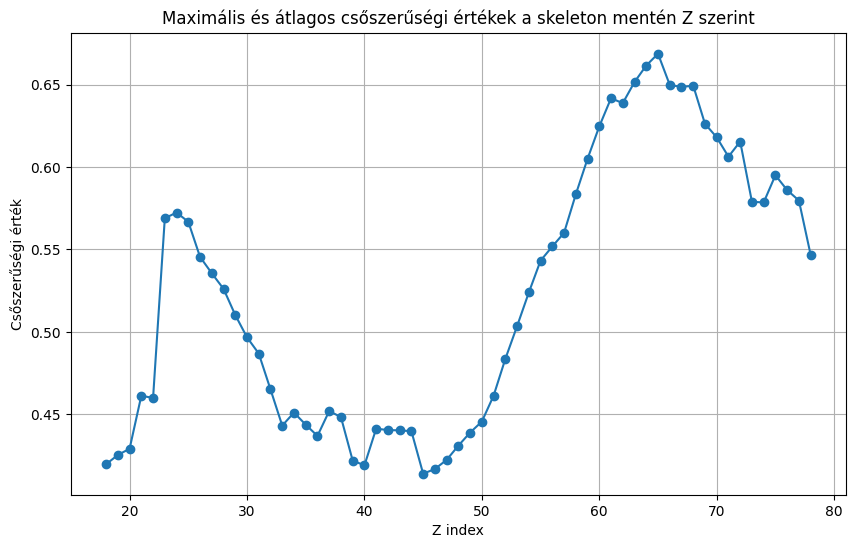

Megtalálva: Z: 65, 0.6687192320823669
Vágási pont megtalálva: Z=65, Y=34, X=19, Normál vektor: [0.94382274 0.32718232 0.04637229]
Vágási pont megtalálva: Z=100, Y=64, X=64, Normál vektor: [0.94382274 0.32718232 0.04637229]
Vágási pont megtalálva: Z=100, Y=64, X=64
A vágási sík a cső és a kamra között


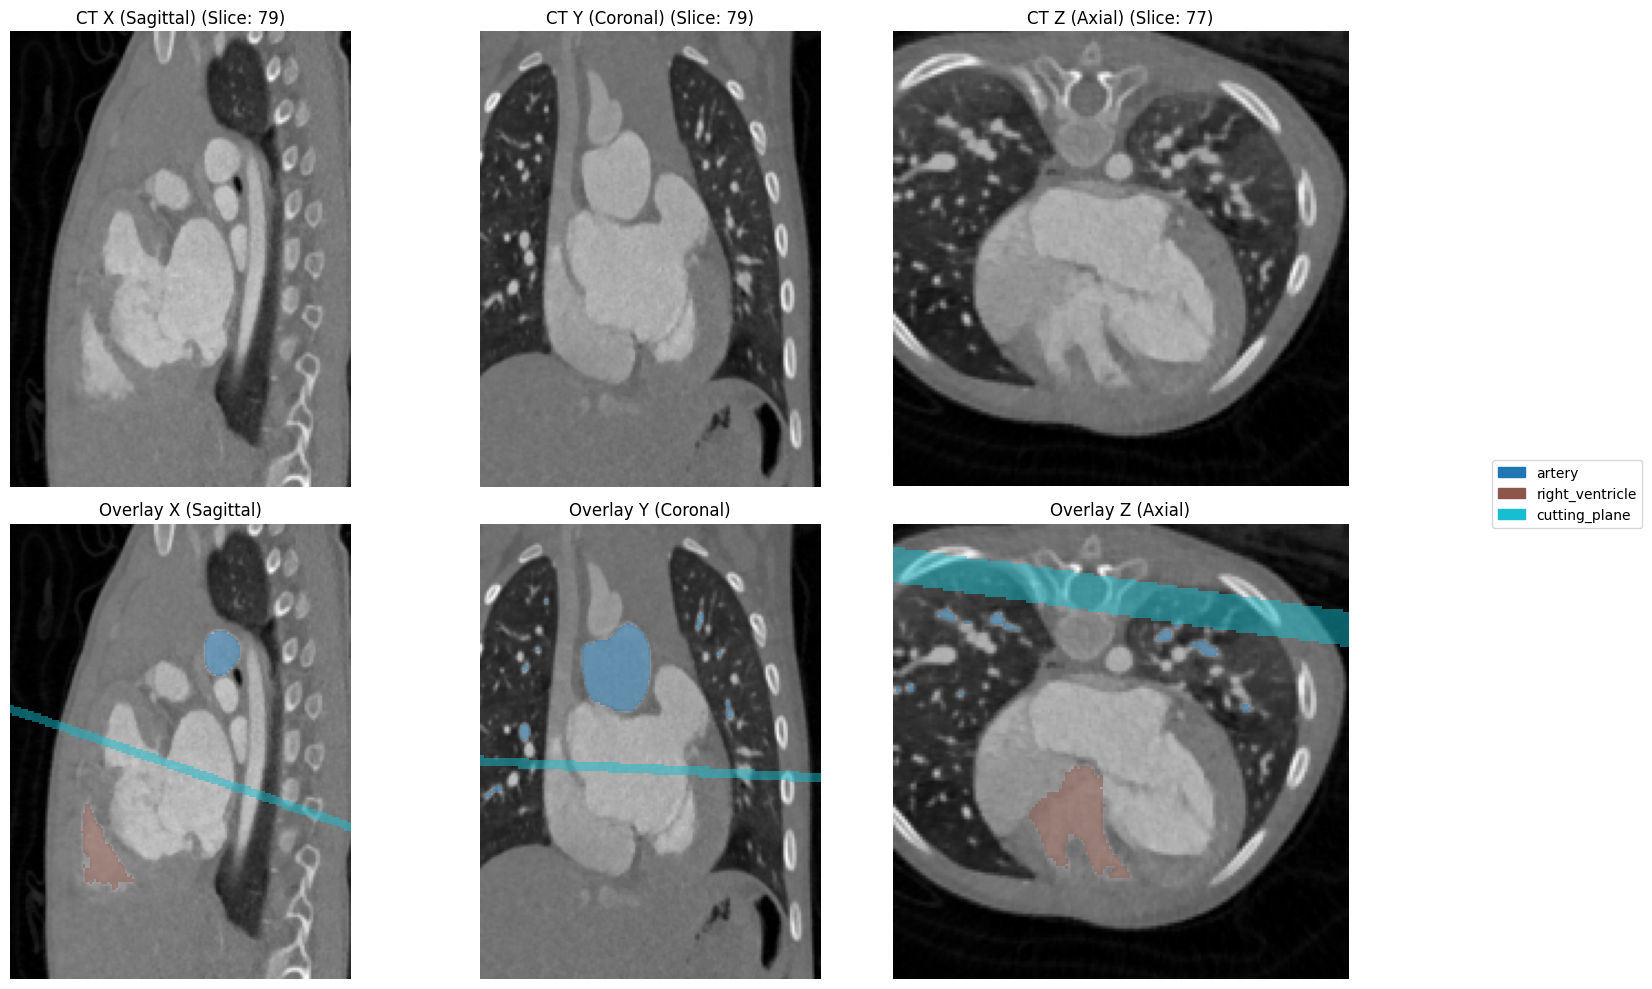

In [434]:
visual_plane_artery, cut_mask_artery = get_dummy_plane(
       ventricle_label=relevant_labels_dic['right_ventricle'],
        tube_label=relevant_labels_dic['artery'],
        ct_array=ct_array,
        ct_image=ct_image,
        out_dir=os.path.join(output_dir, "artery_cutting_plane"),
        tube_type='artery',
        ventricle_type='right_ventricle'
)

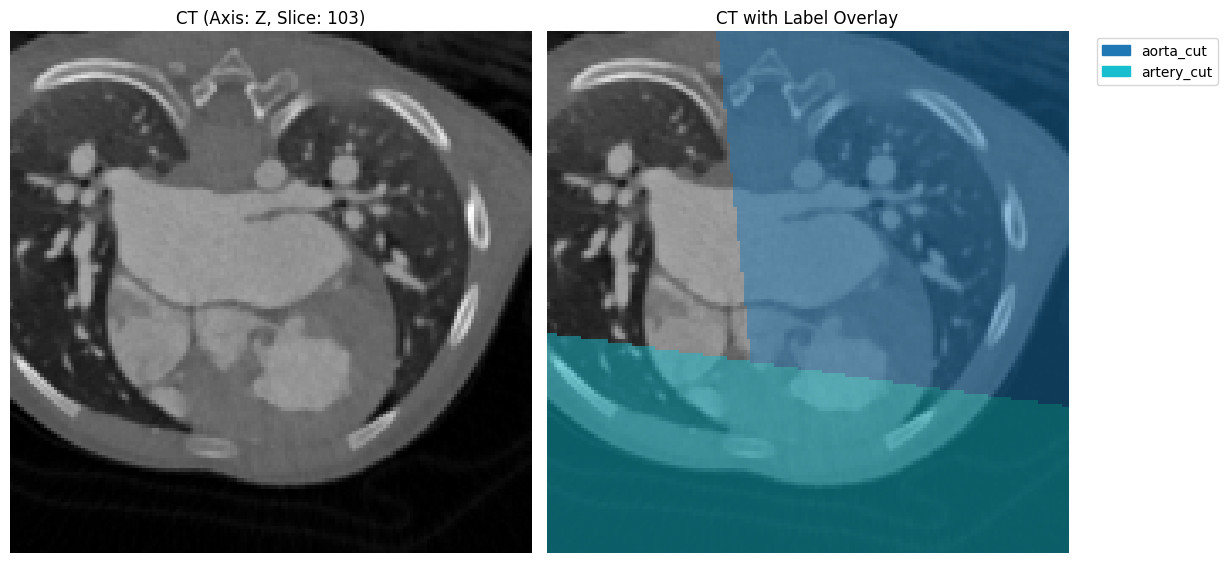

In [435]:
cropped_cut_mask_aorta = ventircles_BB.get_cropped_array(cut_mask_aorta, roi_mask)
cropped_cut_mask_artery = ventircles_BB.get_cropped_array(cut_mask_artery, roi_mask)
    
visualization.plot_slice_with_labels(ct_array, {'aorta_cut': cut_mask_aorta, 'artery_cut': cut_mask_artery}, axis='z', save_path=os.path.join(output_dir, 'cut_masks_overlay.png'))
    

Mátrix építés és sajátérték-számítás full image-re...
Skála: 1.0, 99%-os percentilis S: 136.50938415527344
Mátrix építés és sajátérték-számítás full image-re...
Skála: 2.0, 99%-os percentilis S: 163.1195831298828
Mátrix építés és sajátérték-számítás full image-re...
Skála: 4.0, 99%-os percentilis S: 141.30816650390625
Mátrix építés és sajátérték-számítás full image-re...
Skála: 5.0, 99%-os percentilis S: 129.90380859375
Mátrix építés és sajátérték-számítás full image-re...
Skála: 6.0, 99%-os percentilis S: 124.70765686035156
Mátrix építés és sajátérték-számítás full image-re...
Skála: 7.0, 99%-os percentilis S: 147.0
Mátrix építés és sajátérték-számítás full image-re...
Skála: 8.0, 99%-os percentilis S: 128.0
Mátrix építés és sajátérték-számítás full image-re...
Skála: 9.0, 99%-os percentilis S: 162.0
Mátrix építés és sajátérték-számítás full image-re...
Skála: 10.0, 99%-os percentilis S: 100.0
Használt c érték a sheetness képlethez: 81.5597915649414
 -> Számítás sigma = 1.0 skálán (sh

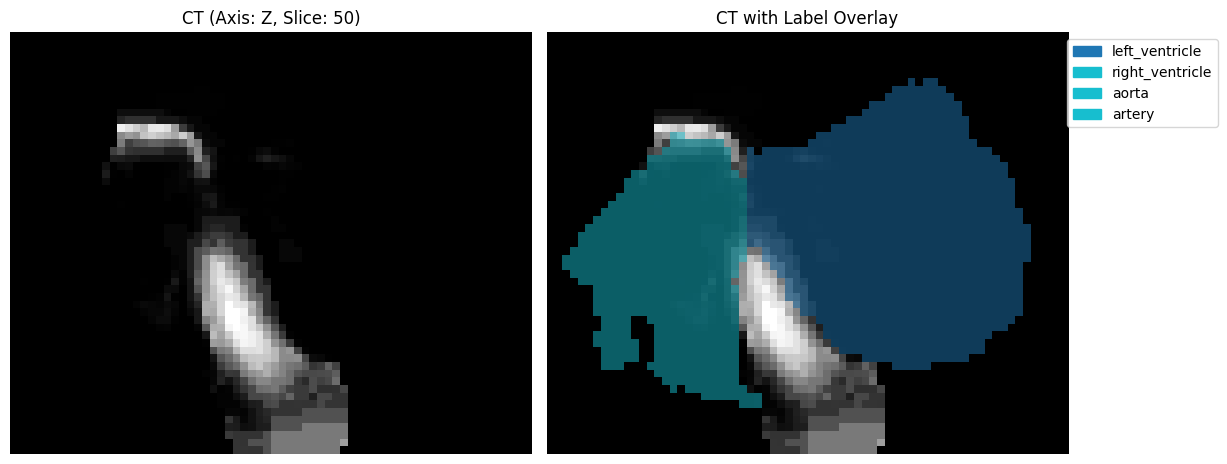

In [436]:
   # Ablakozás (windowing) a CT értékeken, ami a notebook-ban is javítja a sheetness eredményét
cropped_ct_windowed = np.clip(cropped_ct_array, 1000, 1600)
    
    # Filter lefuttatása a windowolt CT-n dinamikusan számolt 'c' konstanssal 
max_scores = filter.multiscale_sheetness_3d(cropped_ct_windowed, sigmas=[1.0, 2.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0], alpha=0.5, beta=0.5)
    
    # A levágott végleges tiszta bal kamra (az aortalefolyás nélkül)
combined_mask = np.logical_and(np.logical_and(cropped_cut_mask_aorta, cropped_cut_mask_artery), septum_mask)
cropped_sheetness = np.where(combined_mask, max_scores, 0)
    
visualization.plot_slice_with_labels(cropped_sheetness, cropped_relevant_labels_dic, axis='z', save_path=os.path.join(output_dir, 'final_sheetness_overlay.png'))
    

In [437]:
 # Visszatesszük a kivágott sheetness eredményt a teljes CT méretű tömbbe
sheetness_full = np.zeros_like(ct_array, dtype=np.float32)
z_idx, y_idx, x_idx = np.nonzero(roi_mask)
if len(z_idx) > 0:
        z_min, z_max = max(0, z_idx.min()), min(ct_array.shape[0], z_idx.max() + 1)
        y_min, y_max = max(0, y_idx.min()), min(ct_array.shape[1], y_idx.max() + 1)
        x_min, x_max = max(0, x_idx.min()), min(ct_array.shape[2], x_idx.max() + 1)
        sheetness_full[z_min:z_max, y_min:y_max, x_min:x_max] = cropped_sheetness
    
output.save_array_as_image(sheetness_full, ct_image, os.path.join(output_dir, 'final_sheetness.nii.gz'))

Kép sikeresen elmentve ide: output\ImageCHD_dataset\ct_1005_iso\final_sheetness.nii.gz
